# Backpropagation from Scratch for Handwritten Digit Recognition

This notebook implements a simple neural network using NumPy only. It includes forward propagation, error calculation, backward propagation, weight updates, and result visualization.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder ready:", RESULTS_DIR)

Results folder ready: results


In [4]:
# Load Dataset
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

print("Data shape:", X.shape)
print("Labels shape:", y.shape)
print("Images shape:", images.shape)

Data shape: (1797, 64)
Labels shape: (1797,)
Images shape: (1797, 8, 8)


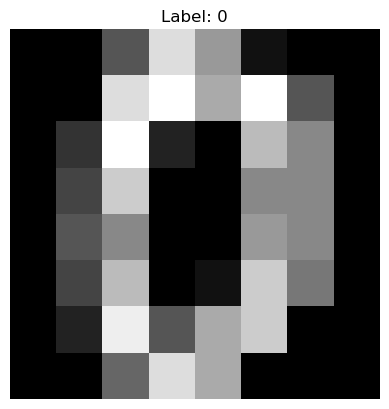

In [5]:
#Sample Image Show
plt.imshow(images[0], cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

In [6]:
# Normalize Data
X = X / 16.0
print("Minimum value:", X.min())
print("Maximum value:", X.max())

Minimum value: 0.0
Maximum value: 1.0


In [7]:
# Train test Split
X_train, X_test, y_train_labels, y_test_labels, img_train, img_test = train_test_split(
    X, y, images, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1437, 64)
Testing data: (360, 64)


In [8]:
#One Hot Function 
def one_hot_encode(labels, num_classes):
    encoded = np.zeros((labels.size, num_classes))
    encoded[np.arange(labels.size), labels] = 1
    return encoded

In [9]:
#Label Encode 
y_train = one_hot_encode(y_train_labels, 10)
y_test = one_hot_encode(y_test_labels, 10)

print("Encoded training labels:", y_train.shape)
print("Encoded testing labels:", y_test.shape)
print("Example encoded label:", y_train[0])

Encoded training labels: (1437, 10)
Encoded testing labels: (360, 10)
Example encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [10]:
#Brain
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5, seed=42):
        rng = np.random.default_rng(seed)
        self.learning_rate = learning_rate
        
        # Input layer to hidden layer weights and bias
        self.W1 = rng.normal(0, np.sqrt(2 / (input_size + hidden_size)), (input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        
        # Hidden layer to output layer weights and bias
        self.W2 = rng.normal(0, np.sqrt(2 / (hidden_size + output_size)), (hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(a):
        return a * (1 - a)

    @staticmethod
    def softmax(z):
        shifted = z - np.max(z, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    @staticmethod
    def cross_entropy(y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def forward(self, X):
        # Input layer to hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Hidden layer to output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)
        
        return self.a2

    def backward(self, X, y_true):
        m = X.shape[0]
        
        # Output layer error
        dz2 = (self.a2 - y_true) / m
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Hidden layer error
        dz1 = (dz2 @ self.W2.T) * self.sigmoid_derivative(self.a1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update weights and biases
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def predict(self, X):
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)

    def train(self, X_train, y_train, X_test, y_test, epochs=500):
        history = {
            "loss": [],
            "train_accuracy": [],
            "test_accuracy": []
        }
        
        y_train_labels = np.argmax(y_train, axis=1)
        y_test_labels = np.argmax(y_test, axis=1)

        for epoch in range(1, epochs + 1):
            # Forward propagation
            y_pred = self.forward(X_train)
            
            # Loss calculation
            loss = self.cross_entropy(y_train, y_pred)
            
            # Backward propagation and weight update
            self.backward(X_train, y_train)

            # Accuracy check
            train_pred = self.predict(X_train)
            test_pred = self.predict(X_test)
            
            train_acc = accuracy_score(y_train_labels, train_pred)
            test_acc = accuracy_score(y_test_labels, test_pred)

            # Save history
            history["loss"].append(loss)
            history["train_accuracy"].append(train_acc)
            history["test_accuracy"].append(test_acc)

            # Print progress
            if epoch % 50 == 0 or epoch == 1:
                print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
        
        return history

In [11]:
model = NeuralNetwork(input_size=64, hidden_size=32, output_size=10, learning_rate=0.5, seed=42)
print("Model created successfully")

Model created successfully


In [12]:
#Testing
history = model.train(X_train, y_train, X_test, y_test, epochs=500)

Epoch 001 | Loss: 2.4302 | Train Acc: 0.0522 | Test Acc: 0.0556
Epoch 050 | Loss: 1.6254 | Train Acc: 0.8100 | Test Acc: 0.8056
Epoch 100 | Loss: 0.9060 | Train Acc: 0.8991 | Test Acc: 0.8806
Epoch 150 | Loss: 0.5784 | Train Acc: 0.9193 | Test Acc: 0.9056
Epoch 200 | Loss: 0.4211 | Train Acc: 0.9290 | Test Acc: 0.9222
Epoch 250 | Loss: 0.3320 | Train Acc: 0.9422 | Test Acc: 0.9250
Epoch 300 | Loss: 0.2757 | Train Acc: 0.9520 | Test Acc: 0.9278
Epoch 350 | Loss: 0.2372 | Train Acc: 0.9596 | Test Acc: 0.9333
Epoch 400 | Loss: 0.2092 | Train Acc: 0.9610 | Test Acc: 0.9389
Epoch 450 | Loss: 0.1879 | Train Acc: 0.9652 | Test Acc: 0.9417
Epoch 500 | Loss: 0.1711 | Train Acc: 0.9666 | Test Acc: 0.9444


In [13]:
#Final
predictions = model.predict(X_test)
final_accuracy = accuracy_score(y_test_labels, predictions)

print("Final Test Accuracy:", round(final_accuracy, 4))

Final Test Accuracy: 0.9444


In [14]:
#Classification
report = classification_report(y_test_labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.86      0.83      0.85        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.90      1.00      0.95        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.92      0.97      0.95        36
           8       0.90      0.80      0.85        35
           9       0.91      0.89      0.90        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



In [15]:
#Confusion Matrix
cm = confusion_matrix(y_test_labels, predictions)
print(cm)

[[35  0  0  0  1  0  0  0  0  0]
 [ 0 30  0  0  0  1  1  0  1  3]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  1  0  0 35  0  0]
 [ 0  5  0  0  0  0  0  2 28  0]
 [ 0  0  0  0  2  0  0  1  1 32]]


In [16]:
#Final predictions
predictions = model.predict(X_test)

print("Predictions shape:", predictions.shape)
print("First 10 predictions:", predictions[:10])
print("First 10 actual labels:", y_test_labels[:10])

Predictions shape: (360,)
First 10 predictions: [5 2 8 6 7 2 6 2 6 5]
First 10 actual labels: [5 2 8 1 7 2 6 2 6 5]


In [17]:
#Final Accuracy
final_accuracy = accuracy_score(y_test_labels, predictions)

print("Final Test Accuracy:", round(final_accuracy, 4))
print("Final Test Accuracy Percentage:", round(final_accuracy * 100, 2), "%")

Final Test Accuracy: 0.9444
Final Test Accuracy Percentage: 94.44 %


In [18]:
#Classification matrix
report = classification_report(y_test_labels, predictions)

print(report)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.86      0.83      0.85        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.90      1.00      0.95        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.92      0.97      0.95        36
           8       0.90      0.80      0.85        35
           9       0.91      0.89      0.90        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



In [19]:
#COnfusion Matrix
cm = confusion_matrix(y_test_labels, predictions)

print(cm)

[[35  0  0  0  1  0  0  0  0  0]
 [ 0 30  0  0  0  1  1  0  1  3]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  1  0  0 35  0  0]
 [ 0  5  0  0  0  0  0  2 28  0]
 [ 0  0  0  0  2  0  0  1  1 32]]


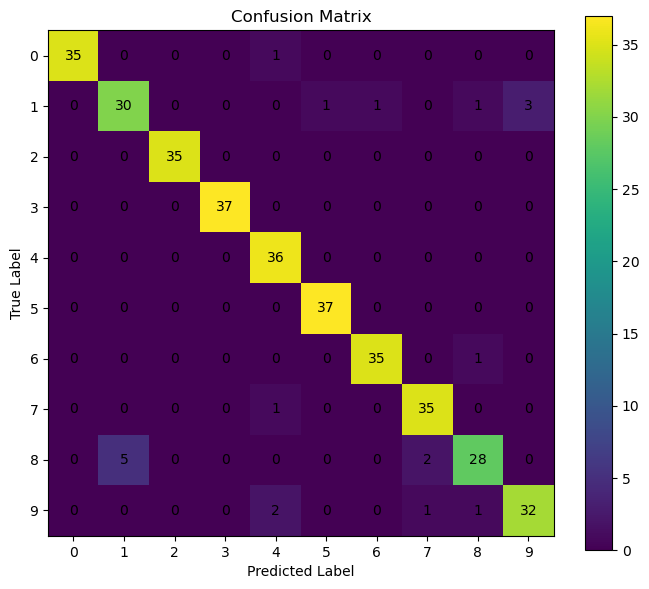

In [20]:
#Image of Confusion Matirx
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

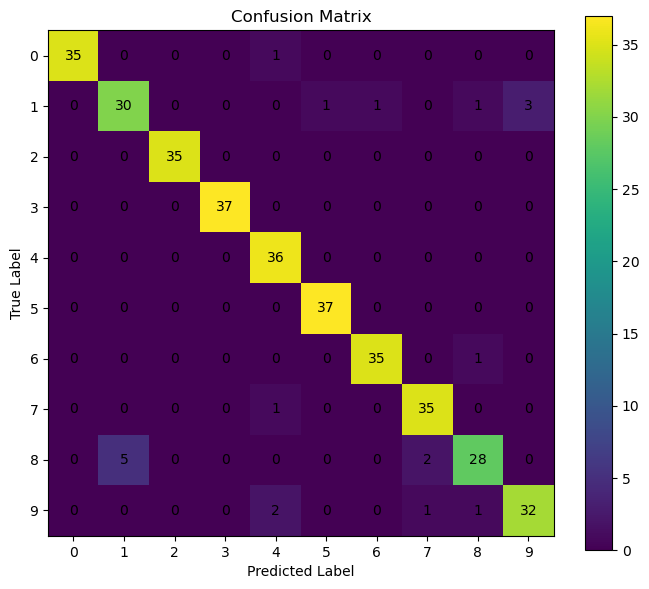

In [21]:
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=180)
plt.show()

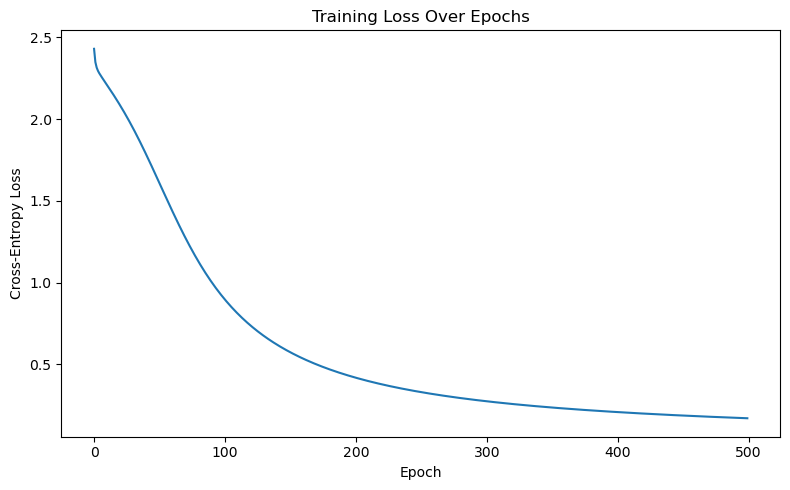

In [22]:
#Training Graph
plt.figure(figsize=(8, 5))
plt.plot(history["loss"])
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.tight_layout()
plt.savefig("results/training_loss.png", dpi=180)
plt.show()

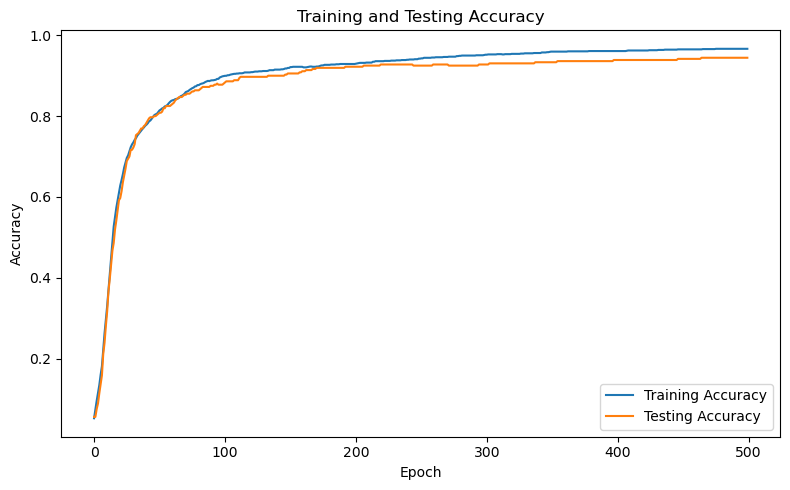

In [23]:
#Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["test_accuracy"], label="Testing Accuracy")
plt.title("Training and Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("results/accuracy_curve.png", dpi=180)
plt.show()

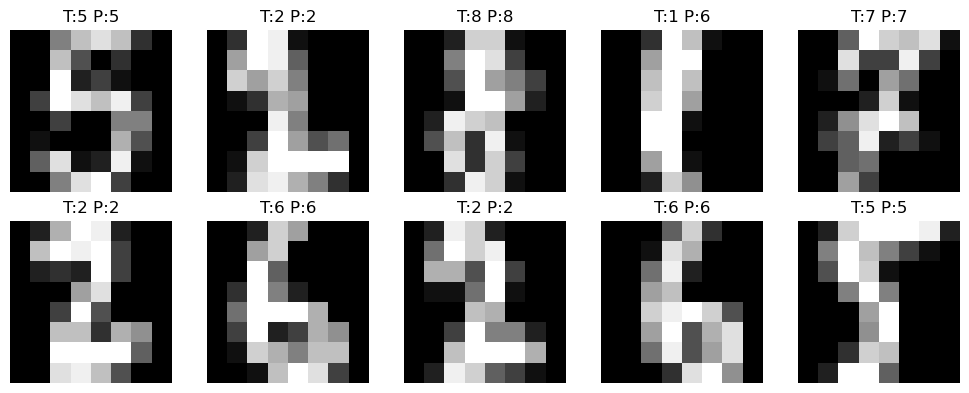

In [24]:
#Sample Predictions
plt.figure(figsize=(10, 4))

for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img_test[idx], cmap="gray")
    plt.title(f"T:{y_test_labels[idx]} P:{predictions[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/sample_predictions.png", dpi=180)
plt.show()

In [25]:
#Accuracy Reporot
with open("results/accuracy_report.txt", "w", encoding="utf-8") as f:
    f.write("Backpropagation Neural Network Results\n")
    f.write("======================================\n")
    f.write("Dataset: sklearn digits handwritten digit dataset\n")
    f.write(f"Training samples: {X_train.shape[0]}\n")
    f.write(f"Testing samples: {X_test.shape[0]}\n")
    f.write("Input neurons: 64\n")
    f.write("Hidden neurons: 32\n")
    f.write("Output neurons: 10\n")
    f.write("Epochs: 500\n")
    f.write("Learning rate: 0.5\n")
    f.write(f"Final test accuracy: {final_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("Accuracy report saved successfully.")

Accuracy report saved successfully.


In [26]:
import os

print("Files saved in results folder:")
for file in os.listdir("results"):
    print(file)

Files saved in results folder:
accuracy_curve.png
accuracy_report.txt
confusion_matrix.png
sample_predictions.png
training_loss.png
